In [156]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

RANDOM_STATE = 42

In [169]:
#Simple plot function to visualize a stock's price over time
def basic_stock_plot(stock_df, stock_ticker):
    plt.figure(figsize=(12,8))
    plt.plot(stock_df['Date'], stock_df['Close'], color = 'red', alpha=0.5)
    title_string = 'Visualization of ' + stock_ticker + ' Stock Price'
    plt.title(title_string)
    plt.xlabel('Date')
    plt.ylabel('Share Price')
    plt.show()

#Format and print a table to compare actual vs. predicted prices
def comp_table(actual_prices, predicted_high_prices, stock_ticker):
    comparison = pd.DataFrame({'Actual': actual_prices.flatten(), 'Predicted': predicted_high_prices.flatten()})
    table_title = stock_ticker + ' Prediction Comparison'
    print(table_title)
    print(comparison)

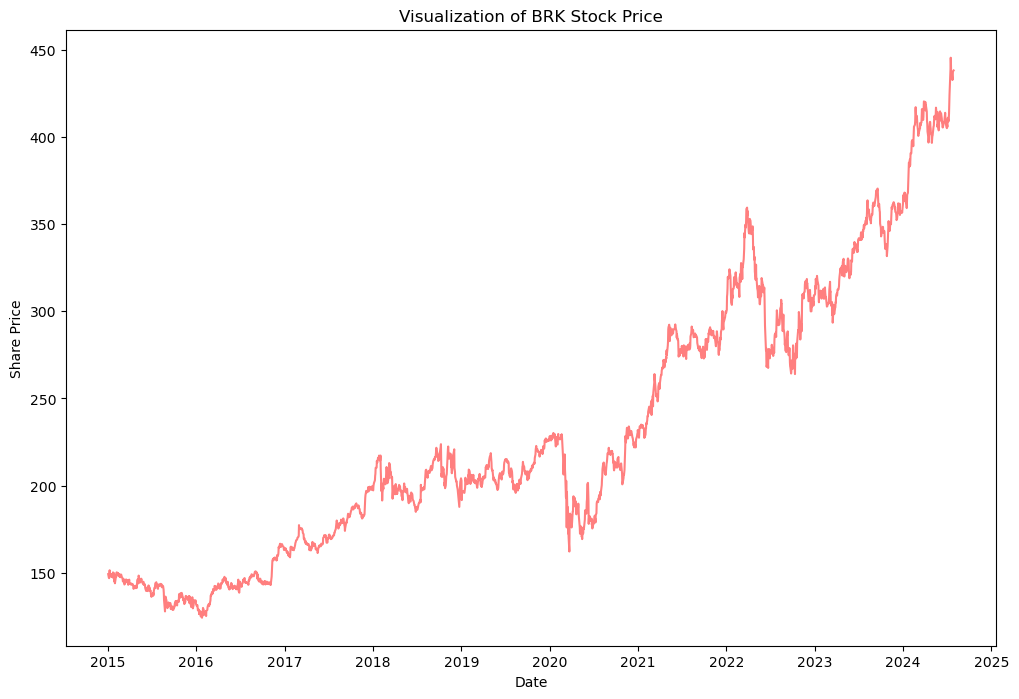

In [170]:
# Import and clean data
data = '../data/BRK.csv'
df = pd.read_csv(data)
df = df.dropna()
df['Date'] = pd.to_datetime(df['Date'])

#Show first few rows of data
df.head(5)

#Basic visualization
basic_stock_plot(df, 'BRK')

In [171]:

# Define features, target. Shift features to match yesterday's features with today's target, since we want to predict tomorrow's price
X = df[['Open', 'High', 'Low', 'Adj Close', 'Volume']].head(-1)
y = df[['Close']].tail(-1).values

# Split data for training, testing
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Scale features to ensure they are weighted evenly
# Initialize scaler object
scaler = StandardScaler()

# Scale the training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale the test data
X_test_scaled = scaler.transform(X_test)

In [173]:
# Construct and train model
forestModel = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
forestModel.fit(X_train_scaled, y_train)

c:\Users\Joey\anaconda3\envs\cs325\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=42)

In [174]:
# Predict with model
y_pred = forestModel.predict(X_test_scaled)

# Calculate and display performance metrics
rfMSE = mean_squared_error(y_test, y_pred)
rfR2 = r2_score(y_test, y_pred)

print(f"Random Forest MSE: {rfMSE}")
print(f"Random Forest R2: {rfR2}")

comp_table(y_test, y_pred, 'BRK')

Random Forest MSE: 10.538280341376739
Random Forest R2: 0.9980851425460625
BRK Prediction Comparison
         Actual   Predicted
0    362.459991  359.401599
1    227.360001  232.046600
2    178.850006  177.873100
3    267.519989  270.157595
4    208.070007  207.175901
..          ...         ...
477  179.660004  184.359600
478  285.929993  286.078000
479  289.880005  288.501597
480  140.729996  141.775797
481  219.029999  219.273100

[482 rows x 2 columns]


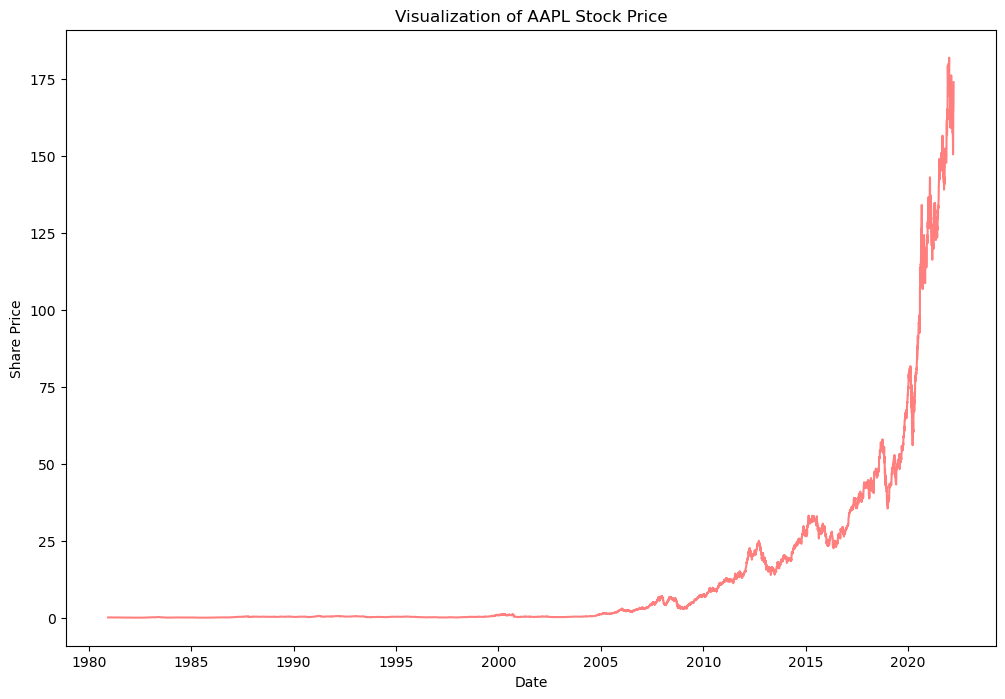

In [175]:
#Import and clean apple stock data
aapl = pd.read_csv('../data/AAPL.csv')

aapl['Date'] = pd.to_datetime(aapl['Date'])
aapl = aapl.dropna()

#Basic visualization
basic_stock_plot(aapl, 'AAPL')

In [176]:
# Define features/targets for apple stock data
X = aapl[['Open', 'High', 'Low', 'Adj Close', 'Volume']].head(-1).values
y = aapl[['Close']].tail(-1).values

# Predict with model trained on BRK
aapl_predicted = forestModel.predict(X)

# Calculate and display performance metrics
rfMSE = mean_squared_error(y, aapl_predicted)
rfR2 = r2_score(y, aapl_predicted)

print(f"Random Forest MSE: {rfMSE}")
print(f"Random Forest R2: {rfR2}")
comp_table(y, aapl_predicted, 'AAPL')

Random Forest MSE: 105733.74669506798
Random Forest R2: -114.99716062787266
AAPL Prediction Comparison
           Actual   Predicted
0        0.121652  245.717402
1        0.112723  244.816301
2        0.115513  244.262000
3        0.118862  244.297601
4        0.126116  244.830901
...           ...         ...
10403  163.979996  438.324305
10404  165.380005  438.324305
10405  168.820007  438.324305
10406  170.210007  438.324305
10407  174.070007  438.324305

[10408 rows x 2 columns]


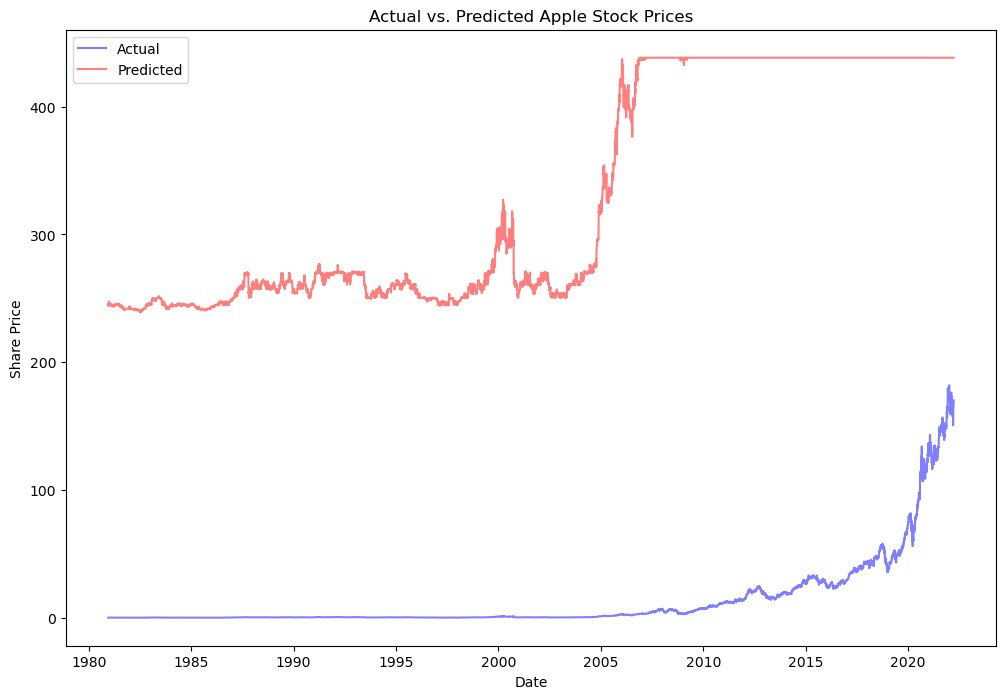

In [177]:
min_length = min(len(aapl['Date']), len(aapl_predicted))
dates = aapl['Date'][:min_length]
actual_prices = aapl['Close'][:min_length]
predicted_prices = aapl_predicted[:min_length]

# Plot the data
plt.figure(figsize=(12, 8))
plt.plot(dates, actual_prices, color='blue', alpha=0.5)
plt.plot(dates, predicted_prices, color='red', alpha=0.5)

plt.title('Actual vs. Predicted Apple Stock Prices')
plt.xlabel('Date')
plt.ylabel('Share Price')
plt.legend(['Actual', 'Predicted'])
plt.show()

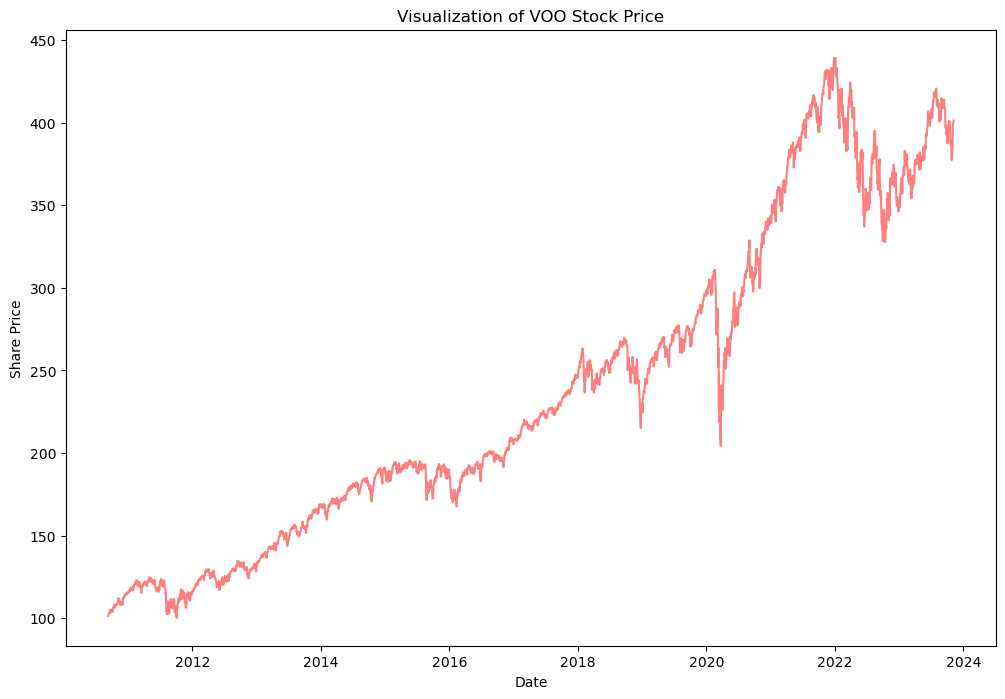

In [178]:
#Import voo (Vanguard S&P 500 ETF) stock data
voo = pd.read_csv('../data/VOO.csv')

#Reorder indices to be consistent with past datasets
voo[:] = voo[::-1]

#Drop rows with missing values, convert date to datetime format, strip whitespace from column names
voo = voo.dropna()
voo['Date'] = pd.to_datetime(voo['Date'], format = '%m/%d/%y')
voo.columns = voo.columns.str.strip()

#Insert new column 'Adj Close' so number of features matches what model expects. (Original voo dataset was lacking data on adjusted closing price)
voo.insert(5, 'Adj Close', voo['Close'], True)

basic_stock_plot(voo, 'VOO')

In [179]:
#Select features and target values
X = voo[['Open', 'High', 'Low', 'Adj Close', 'Volume']].head(-1).values
y = voo[['Close']].tail(-1).values

# Predict with model trained on BRK
voo_predicted = forestModel.predict(X)

# Calculate and display performance metrics
rfMSE = mean_squared_error(y, voo_predicted)
rfR2 = r2_score(y, voo_predicted)

print(f"Random Forest MSE: {rfMSE}")
print(f"Random Forest R2: {rfR2}")
comp_table(y, voo_predicted, 'VOO')

Random Forest MSE: 49374.02443629972
Random Forest R2: -4.512574459915329
VOO Prediction Comparison
       Actual   Predicted
0     101.780  438.324305
1     103.060  438.324305
2     103.038  438.324305
3     103.300  438.324305
4     103.260  438.324305
...       ...         ...
3308  388.400  438.324305
3309  395.780  438.324305
3310  399.440  438.324305
3311  400.210  438.324305
3312  401.340  438.324305

[3313 rows x 2 columns]


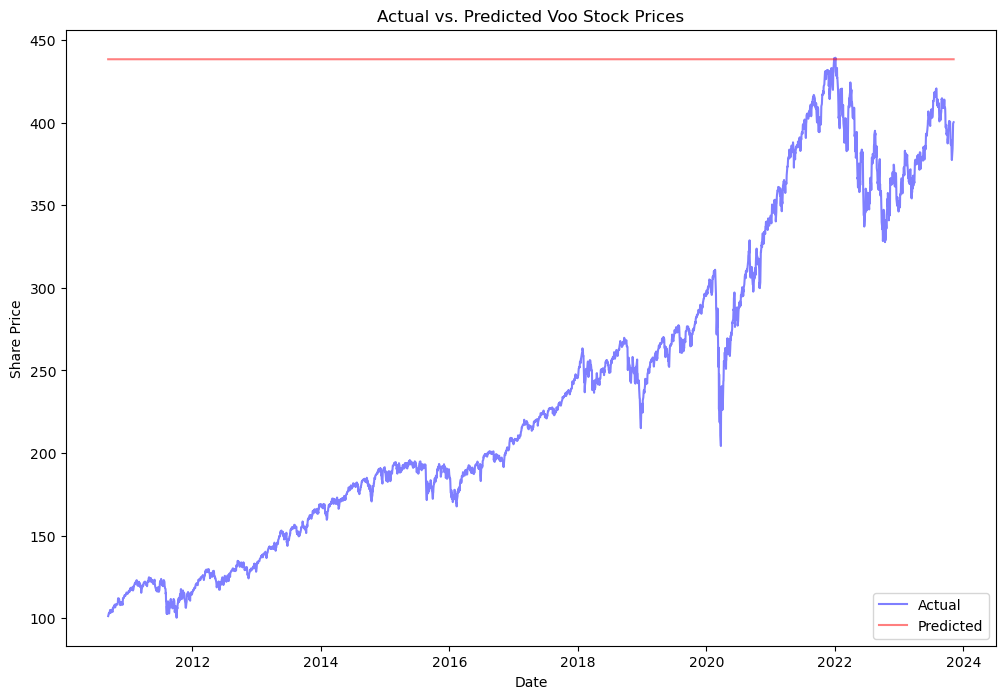

In [180]:
# Convert voo_predicted_high_prices to a 1D array if it's 2D
voo_predicted= voo_predicted.flatten()

# Ensure both arrays have the same length (trim the larger array if needed)
min_length = min(len(voo['Date']), len(voo_predicted))
dates = voo['Date'][:min_length]
actual_prices = voo['Close'][:min_length]
predicted_prices = voo_predicted[:min_length]

# Plot the data
plt.figure(figsize=(12, 8))
plt.plot(dates, actual_prices, color='blue', alpha=0.5)
plt.plot(dates, predicted_prices, color='red', alpha=0.5)

plt.title('Actual vs. Predicted Voo Stock Prices')
plt.xlabel('Date')
plt.ylabel('Share Price')
plt.legend(['Actual', 'Predicted'])
plt.show()